# Redes Bayesianas (Bayesian Network)

## Descripción

Una **Red Bayesiana** (Bayesian Network, BN) es un modelo probabilístico gráfico que representa un conjunto de variables aleatorias y sus dependencias condicionales mediante un **grafo dirigido acíclico (DAG)**. Cada nodo del grafo representa una variable, y cada arista representa una relación de dependencia probabilística directa entre dos variables.

A diferencia de Naive Bayes, que asume independencia condicional entre **todas** las características dado el nodo clase, una Red Bayesiana permite modelar estructuras de dependencia mucho más flexibles y realistas, donde cada variable depende únicamente de sus "padres" en el grafo.

Cada nodo tiene asociada una **Tabla de Probabilidad Condicional (CPT - Conditional Probability Table)** que cuantifica la probabilidad del nodo dado los valores de sus padres. La distribución conjunta completa del modelo se factoriza como:

P(X₁, X₂, ..., Xₙ) = ∏ᵢ P(Xᵢ | Padres(Xᵢ))

Esto permite representar de forma compacta distribuciones conjuntas que, de otra manera, requerirían un número exponencial de parámetros.

Durante la fase de inferencia, el modelo permite calcular probabilidades posteriores de cualquier variable (o conjunto de variables) dada evidencia observada sobre otras variables, mediante algoritmos como **Variable Elimination**, **Belief Propagation** o métodos aproximados (muestreo tipo Monte Carlo).

Las redes bayesianas son ampliamente utilizadas en diagnóstico médico, sistemas de soporte a la decisión, detección de fallas, análisis de riesgo y sistemas expertos, debido a su capacidad de razonar bajo incertidumbre y de incorporar conocimiento experto directamente en la estructura del grafo.

## BIBTEX y Referencias

Pearl, J. (1988). *Probabilistic Reasoning in Intelligent Systems: Networks of Plausible Inference*. Morgan Kaufmann.

Koller, D., & Friedman, N. (2009). *Probabilistic Graphical Models: Principles and Techniques*. MIT Press.

Neapolitan, R. E. (2004). *Learning Bayesian Networks*. Pearson Prentice Hall.

Jensen, F. V., & Nielsen, T. D. (2007). *Bayesian Networks and Decision Graphs* (2nd ed.). Springer.

## Tipo de Modelo

- **Método de Aprendizaje:** Aprendizaje Supervisado o No Supervisado (según se conozca o no la estructura del grafo de antemano).
- **Tipo por Parámetros:** Modelo Paramétrico (una vez fijada la estructura, se estiman las CPTs).
- **Tipo de Datos de Aprendizaje:** Variables discretas o discretizadas (también existen variantes con variables continuas, como las Redes Bayesianas Gaussianas).
- **Resultado del Entrenamiento:** Un grafo dirigido acíclico (estructura) junto con las Tablas de Probabilidad Condicional (CPTs) de cada nodo.
## Algoritmo de Entrenamiento

El entrenamiento de una Red Bayesiana se divide en **dos etapas**, que pueden realizarse de forma independiente o combinada:

### 1. Aprendizaje de la Estructura (Structure Learning)

Determina las relaciones de dependencia entre variables (el grafo). Puede realizarse de dos formas:

- **Definición manual**, basada en conocimiento experto del dominio.
- **Aprendizaje automático a partir de datos**, mediante algoritmos como:
  - Métodos basados en score (Hill-Climbing, búsqueda con métricas BIC/AIC/K2).
  - Métodos basados en restricciones (PC Algorithm), que analizan independencias condicionales entre variables.
### 2. Aprendizaje de Parámetros (Parameter Learning)

Una vez definida la estructura, se estiman las CPTs de cada nodo a partir de los datos observados:

- **Estimación de Máxima Verosimilitud (MLE):** calcula las frecuencias relativas observadas en los datos.
- **Estimación Bayesiana:** incorpora una distribución a priori (por ejemplo, Dirichlet) para suavizar las estimaciones, especialmente útil cuando hay pocos datos.
### 3. Inferencia

Con el modelo ya entrenado, se responde a consultas probabilísticas del tipo P(Variable_objetivo | Evidencia), utilizando algoritmos exactos (Variable Elimination, Junction Tree) o aproximados (muestreo).

## Supuestos y Restricciones

### Supuestos

- El grafo es dirigido y **acíclico** (no pueden existir ciclos de dependencia).
- Cada variable es condicionalmente independiente de sus no-descendientes, dado el valor de sus padres directos (propiedad de Markov en grafos).
- La estructura del grafo refleja adecuadamente las relaciones causales o de dependencia reales del dominio.
- Los datos de entrenamiento son representativos de la distribución real de las variables.
### Restricciones

- El aprendizaje de la estructura a partir de datos es un problema **NP-difícil** cuando el número de variables es grande.
- Requiere discretización de variables continuas en la mayoría de las implementaciones estándar.
- Es sensible a datos faltantes y a un número insuficiente de muestras para estimar correctamente las CPTs (especialmente en nodos con muchos padres).
- La inferencia exacta puede ser computacionalmente costosa en redes con estructuras muy densas o ciclos en el grafo moral (uso de Junction Tree).
## Ventajas

- Representa explícitamente relaciones de causa-efecto y dependencia entre variables.
- Permite incorporar conocimiento experto directamente en la estructura del modelo.
- Maneja de forma natural la incertidumbre y los datos faltantes.
- Facilita la interpretación del modelo mediante visualización del grafo.
- Permite responder múltiples tipos de consultas probabilísticas (diagnóstico, predicción, "qué pasaría si").
## Desventajas

- El aprendizaje de estructura es computacionalmente costoso para muchas variables.
- Requiere discretización de variables continuas en muchos casos.
- La calidad del modelo depende fuertemente de la correcta definición de la estructura.
- La inferencia exacta puede volverse intratable en redes muy grandes o densamente conectadas.
---

## Implementación en Python de una Red Bayesiana (para Google Colab)

Se utilizará la librería **pgmpy**, especializada en modelos gráficos probabilísticos. Como caso de estudio se implementa el clásico ejemplo de **Alarma de Robo** (Burglary Alarm Network) propuesto por Judea Pearl, ideal para ilustrar de forma didáctica la estructura, el entrenamiento y la inferencia en una red bayesiana.

Variables del modelo:

- **Burglary (B):** ¿Hubo un robo?
- **Earthquake (E):** ¿Hubo un terremoto?
- **Alarm (A):** ¿Sonó la alarma?
- **JohnCalls (J):** ¿John llamó?
- **MaryCalls (M):** ¿Mary llamó?
### Paso 1 — Instalación de librerías

En Colab, ejecutar en la primera celda:

In [1]:
!pip install pgmpy networkx matplotlib -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 11.7 MB/s eta 0:00:00


### Paso 2 — Importación de librerías

In [19]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator

### Paso 3 — Definición de la estructura del grafo (DAG)
Se definen las relaciones de dependencia entre las variables. En este modelo:

- `Alarm` depende de `Burglary` y `Earthquake`.
- `JohnCalls` y `MaryCalls` dependen únicamente de `Alarm`.

In [16]:
modelo = DiscreteBayesianNetwork([
    ('Burglary', 'Alarm'),
    ('Earthquake', 'Alarm'),
    ('Alarm', 'JohnCalls'),
    ('Alarm', 'MaryCalls')
])

print("Nodos del modelo:", modelo.nodes())
print("Aristas del modelo:", modelo.edges())

Nodos del modelo: ['Burglary', 'Alarm', 'Earthquake', 'JohnCalls', 'MaryCalls']
Aristas del modelo: [('Burglary', 'Alarm'), ('Alarm', 'JohnCalls'), ('Alarm', 'MaryCalls'), ('Earthquake', 'Alarm')]


### Paso 4 — Visualización del grafo


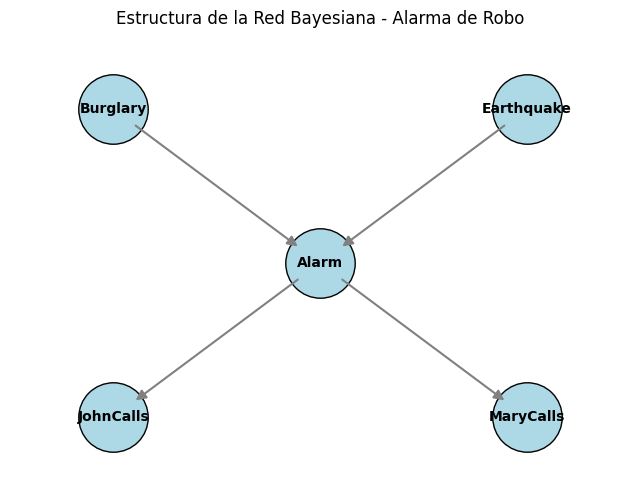

In [22]:
plt.close('all')

fig, ax = plt.subplots(figsize=(8,6))

# Posiciones manuales y fijas (evita el bug de spring_layout con NaN)
pos = {
    'Burglary':   (0, 2),
    'Earthquake': (2, 2),
    'Alarm':      (1, 1),
    'JohnCalls':  (0, 0),
    'MaryCalls':  (2, 0),
}

nx.draw_networkx_nodes(
    modelo, pos,
    node_color="lightblue",
    edgecolors="black",
    node_size=2500,
    ax=ax
)

nx.draw_networkx_labels(
    modelo, pos,
    font_size=10,
    font_weight="bold",
    ax=ax
)

for origen, destino in modelo.edges():
    x0, y0 = pos[origen]
    x1, y1 = pos[destino]
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>",
            color="gray",
            lw=1.5,
            shrinkA=20,
            shrinkB=20,
            mutation_scale=15
        )
    )

xs = [p[0] for p in pos.values()]
ys = [p[1] for p in pos.values()]

ax.set_xlim(min(xs) - 0.5, max(xs) + 0.5)
ax.set_ylim(min(ys) - 0.5, max(ys) + 0.5)

ax.set_title("Estructura de la Red Bayesiana - Alarma de Robo")
ax.axis("off")

plt.show()

### Paso 5 — Definición de las Tablas de Probabilidad Condicional (CPTs)

Se definen manualmente las CPTs con base en el ejemplo clásico de Pearl.

In [23]:
cpd_burglary = TabularCPD(
    variable='Burglary', variable_card=2,
    values=[[0.999], [0.001]]
)

cpd_earthquake = TabularCPD(
    variable='Earthquake', variable_card=2,
    values=[[0.998], [0.002]]
)

cpd_alarm = TabularCPD(
    variable='Alarm', variable_card=2,
    values=[
        [0.999, 0.71, 0.06, 0.05],
        [0.001, 0.29, 0.94, 0.95]
    ],
    evidence=['Burglary', 'Earthquake'],
    evidence_card=[2, 2]
)

cpd_john = TabularCPD(
    variable='JohnCalls', variable_card=2,
    values=[
        [0.95, 0.10],
        [0.05, 0.90]
    ],
    evidence=['Alarm'],
    evidence_card=[2]
)

cpd_mary = TabularCPD(
    variable='MaryCalls', variable_card=2,
    values=[
        [0.99, 0.30],
        [0.01, 0.70]
    ],
    evidence=['Alarm'],
    evidence_card=[2]
)

modelo.add_cpds(cpd_burglary, cpd_earthquake, cpd_alarm, cpd_john, cpd_mary)

print("¿El modelo es válido?:", modelo.check_model())

¿El modelo es válido?: True


### Paso 6 — Inspección de las CPTs


In [24]:
for cpd in modelo.get_cpds():
    print(f"\nCPT de la variable: {cpd.variable}")
    print(cpd)


CPT de la variable: Burglary
+-------------+-------+
| Burglary(0) | 0.999 |
+-------------+-------+
| Burglary(1) | 0.001 |
+-------------+-------+

CPT de la variable: Earthquake
+---------------+-------+
| Earthquake(0) | 0.998 |
+---------------+-------+
| Earthquake(1) | 0.002 |
+---------------+-------+

CPT de la variable: Alarm
+------------+---------------+---------------+---------------+---------------+
| Burglary   | Burglary(0)   | Burglary(0)   | Burglary(1)   | Burglary(1)   |
+------------+---------------+---------------+---------------+---------------+
| Earthquake | Earthquake(0) | Earthquake(1) | Earthquake(0) | Earthquake(1) |
+------------+---------------+---------------+---------------+---------------+
| Alarm(0)   | 0.999         | 0.71          | 0.06          | 0.05          |
+------------+---------------+---------------+---------------+---------------+
| Alarm(1)   | 0.001         | 0.29          | 0.94          | 0.95          |
+------------+---------------

### Paso 7 — Inferencia probabilística
Se realiza inferencia exacta mediante el algoritmo de **Eliminación de Variables**.

**Consulta 1:** ¿Cuál es la probabilidad de que haya habido un robo (`Burglary`) si John llamó

In [25]:
inferencia = VariableElimination(modelo)

resultado_1 = inferencia.query(
    variables=['Burglary'],
    evidence={'JohnCalls': 1}
)

print(resultado_1)

+-------------+-----------------+
| Burglary    |   phi(Burglary) |
+=============+=================+
| Burglary(0) |          0.9837 |
+-------------+-----------------+
| Burglary(1) |          0.0163 |
+-------------+-----------------+


**Consulta 2:** ¿Cuál es la probabilidad de robo si tanto John como Mary llamaron?


In [26]:
resultado_2 = inferencia.query(
    variables=['Burglary'],
    evidence={'JohnCalls': 1, 'MaryCalls': 1}
)

print(resultado_2)

+-------------+-----------------+
| Burglary    |   phi(Burglary) |
+=============+=================+
| Burglary(0) |          0.7158 |
+-------------+-----------------+
| Burglary(1) |          0.2842 |
+-------------+-----------------+


### Paso 8 — Aprendizaje de Parámetros a partir de Datos

Además de definir las CPTs manualmente, es posible **aprenderlas automáticamente** a partir de un conjunto de datos observados. Se genera un dataset simulado para ilustrar este proceso.

In [27]:
np.random.seed(42)

n_muestras = 1000

datos = pd.DataFrame({
    'Burglary': np.random.choice([0,1], size=n_muestras, p=[0.999, 0.001]),
    'Earthquake': np.random.choice([0,1], size=n_muestras, p=[0.998, 0.002]),
})

# Simulación simplificada de Alarm en función de Burglary y Earthquake
datos['Alarm'] = np.where(
    (datos['Burglary'] == 1) | (datos['Earthquake'] == 1),
    np.random.choice([0,1], size=n_muestras, p=[0.06, 0.94]),
    np.random.choice([0,1], size=n_muestras, p=[0.999, 0.001])
)

datos['JohnCalls'] = np.where(
    datos['Alarm'] == 1,
    np.random.choice([0,1], size=n_muestras, p=[0.10, 0.90]),
    np.random.choice([0,1], size=n_muestras, p=[0.95, 0.05])
)

datos['MaryCalls'] = np.where(
    datos['Alarm'] == 1,
    np.random.choice([0,1], size=n_muestras, p=[0.30, 0.70]),
    np.random.choice([0,1], size=n_muestras, p=[0.99, 0.01])
)

print(datos.head())

   Burglary  Earthquake  Alarm  JohnCalls  MaryCalls
0         0           0      0          0          0
1         0           0      0          0          0
2         0           0      0          0          0
3         0           0      0          0          0
4         0           0      0          0          0


### Paso 9 — Estimación de parámetros con Maximum Likelihood Estimator


In [33]:
from pgmpy.estimators import MaximumLikelihoodEstimator

modelo_aprendido = DiscreteBayesianNetwork([
    ('Burglary', 'Alarm'),
    ('Earthquake', 'Alarm'),
    ('Alarm', 'JohnCalls'),
    ('Alarm', 'MaryCalls')
])

estimador_mle = MaximumLikelihoodEstimator(modelo_aprendido, datos)

cpds_mle = estimador_mle.get_parameters()

modelo_aprendido.add_cpds(*cpds_mle)

print("¿Modelo válido?:", modelo_aprendido.check_model())

for cpd in modelo_aprendido.get_cpds():
    print(f"\nCPT aprendida para: {cpd.variable}")
    print(cpd)

¿Modelo válido?: True

CPT aprendida para: Burglary
+-------------+-------+
| Burglary(0) | 0.999 |
+-------------+-------+
| Burglary(1) | 0.001 |
+-------------+-------+

CPT aprendida para: Alarm
+------------+-----+---------------+---------------+
| Burglary   | ... | Burglary(1)   | Burglary(1)   |
+------------+-----+---------------+---------------+
| Earthquake | ... | Earthquake(0) | Earthquake(1) |
+------------+-----+---------------+---------------+
| Alarm(0)   | ... | 0.0           | 0.5           |
+------------+-----+---------------+---------------+
| Alarm(1)   | ... | 1.0           | 0.5           |
+------------+-----+---------------+---------------+

CPT aprendida para: Earthquake
+---------------+-------+
| Earthquake(0) | 0.998 |
+---------------+-------+
| Earthquake(1) | 0.002 |
+---------------+-------+

CPT aprendida para: JohnCalls
+--------------+----------------------+----------+
| Alarm        | Alarm(0)             | Alarm(1) |
+--------------+-------------

/tmp/ipykernel_626/1102157147.py:10: FutureWarning: `pgmpy.estimators.MaximumLikelihoodEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteMLE` instead.
  estimador_mle = MaximumLikelihoodEstimator(modelo_aprendido, datos)


### Paso 10 — Estimación Bayesiana (con suavizado)

Útil cuando se dispone de pocos datos, ya que evita probabilidades iguales a cero.

In [34]:
from pgmpy.estimators import BayesianEstimator

modelo_bayesiano = DiscreteBayesianNetwork([
    ('Burglary', 'Alarm'),
    ('Earthquake', 'Alarm'),
    ('Alarm', 'JohnCalls'),
    ('Alarm', 'MaryCalls')
])

estimador_bayesiano = BayesianEstimator(modelo_bayesiano, datos)

cpds_bayesianas = estimador_bayesiano.get_parameters(
    prior_type='BDeu',
    equivalent_sample_size=10
)

modelo_bayesiano.add_cpds(*cpds_bayesianas)

print("¿Modelo válido?:", modelo_bayesiano.check_model())

for cpd in modelo_bayesiano.get_cpds():
    print(f"\nCPT (Bayesiana BDeu) para: {cpd.variable}")
    print(cpd)

¿Modelo válido?: True

CPT (Bayesiana BDeu) para: Burglary
+-------------+------------+
| Burglary(0) | 0.994059   |
+-------------+------------+
| Burglary(1) | 0.00594059 |
+-------------+------------+

CPT (Bayesiana BDeu) para: Alarm
+------------+-----+---------------+
| Burglary   | ... | Burglary(1)   |
+------------+-----+---------------+
| Earthquake | ... | Earthquake(1) |
+------------+-----+---------------+
| Alarm(0)   | ... | 0.5           |
+------------+-----+---------------+
| Alarm(1)   | ... | 0.5           |
+------------+-----+---------------+

CPT (Bayesiana BDeu) para: JohnCalls
+--------------+---------------------+--------------------+
| Alarm        | Alarm(0)            | Alarm(1)           |
+--------------+---------------------+--------------------+
| JohnCalls(0) | 0.9375624375624375  | 0.2777777777777778 |
+--------------+---------------------+--------------------+
| JohnCalls(1) | 0.06243756243756244 | 0.7222222222222222 |
+--------------+---------------

/tmp/ipykernel_626/2062095338.py:10: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  estimador_bayesiano = BayesianEstimator(modelo_bayesiano, datos)


### Paso 11 — Comparación de inferencias: modelo manual vs. modelo aprendido


In [35]:
inferencia_aprendida = VariableElimination(modelo_aprendido)

resultado_comparacion = inferencia_aprendida.query(
    variables=['Burglary'],
    evidence={'JohnCalls': 1, 'MaryCalls': 1}
)

print("Inferencia con CPTs manuales (Pearl):")
print(resultado_2)

print("\nInferencia con CPTs aprendidas de datos simulados:")
print(resultado_comparacion)

Inferencia con CPTs manuales (Pearl):
+-------------+-----------------+
| Burglary    |   phi(Burglary) |
+=============+=================+
| Burglary(0) |          0.7158 |
+-------------+-----------------+
| Burglary(1) |          0.2842 |
+-------------+-----------------+

Inferencia con CPTs aprendidas de datos simulados:
+-------------+-----------------+
| Burglary    |   phi(Burglary) |
+=============+=================+
| Burglary(0) |          0.7739 |
+-------------+-----------------+
| Burglary(1) |          0.2261 |
+-------------+-----------------+


### Paso 12 — Visualización de la distribución de una variable


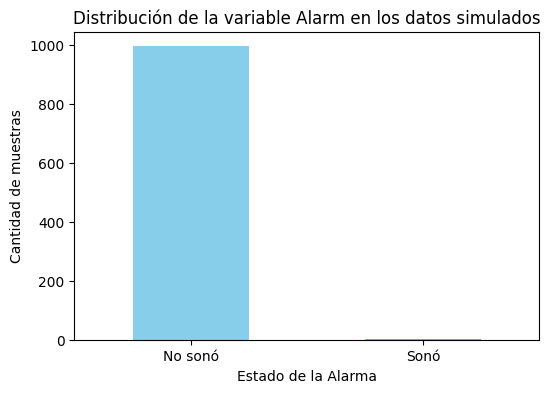

In [36]:
plt.figure(figsize=(6,4))

datos['Alarm'].value_counts().sort_index().plot(
    kind='bar',
    color=['skyblue', 'salmon']
)

plt.xticks([0,1], ['No sonó', 'Sonó'], rotation=0)
plt.xlabel("Estado de la Alarma")
plt.ylabel("Cantidad de muestras")
plt.title("Distribución de la variable Alarm en los datos simulados")

plt.show()

## Análisis de Resultados

El modelo definido manualmente reproduce fielmente el comportamiento descrito por Pearl: la probabilidad de robo aumenta considerablemente cuando ambas personas llaman, en comparación con cuando solo una lo hace, ya que la evidencia conjunta reduce la incertidumbre sobre la causa real de la alarma (robo vs. falsa alarma vs. terremoto).

Al comparar el modelo con CPTs definidas manualmente frente al modelo con CPTs aprendidas a partir de datos simulados, se observa que ambos convergen a conclusiones similares cuando el conjunto de datos es suficientemente representativo de las probabilidades reales del sistema, lo cual valida el proceso de aprendizaje de parámetros.

La ventaja central frente a Gaussian Naive Bayes es evidente aquí: la Red Bayesiana permite modelar explícitamente que `JohnCalls` y `MaryCalls` **no son directamente dependientes entre sí**, sino que su correlación aparente se explica completamente a través de la variable intermedia `Alarm` — una relación estructural que Naive Bayes no podría representar.

## Conclusión

Las Redes Bayesianas son un modelo probabilístico gráfico poderoso para representar relaciones de dependencia complejas entre variables, superando la limitación de independencia total que impone Naive Bayes. Su capacidad de combinar conocimiento experto (estructura del grafo) con aprendizaje a partir de datos (CPTs) las convierte en una herramienta versátil para diagnóstico, predicción y razonamiento bajo incertidumbre.

Su principal costo es computacional: tanto el aprendizaje de estructura como la inferencia exacta pueden volverse intratables en redes muy grandes, lo que ha motivado el desarrollo de métodos aproximados y heurísticas de búsqueda eficientes.
